Import the libraries.

In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
from keras.layers import Dense, Dropout
from keras.models import Sequential
from keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

I0000 00:00:1784480414.756867 1079622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784480414.759991 1079622 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784480414.825385 1079622 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784480416.800910 1079622 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Create the dataset.

In [2]:
x_train = np.linspace(-1,1,20)

In [3]:
y_train = np.array([-0.6561 , -0.3099 , -0.59035, -0.50855, -0.285  , 
                    -0.2443 , -0.02445,  0.00135, -0.2006 ,  0.07475, 
                    -0.1422 ,  0.06515,  0.15265,  0.3521 ,  0.28415,  
                    0.5524 ,  0.23115,  0.20835, 0.4211,  0.60485])

In [4]:
x_test = np.linspace(-1,1,20)

In [5]:
y_test = np.array([-0.69415, -0.451  , -0.43005, -0.4484 , -0.1475 ,
                   -0.5019 , -0.28055,  0.24595, -0.21425, -0.0286 ,  
                   0.23415,  0.46575, 0.07955,  0.1973 ,  0.0719 ,
                   0.3639 ,  0.5536 ,  0.3365 , 0.50705,  0.33435])

Plot the data.

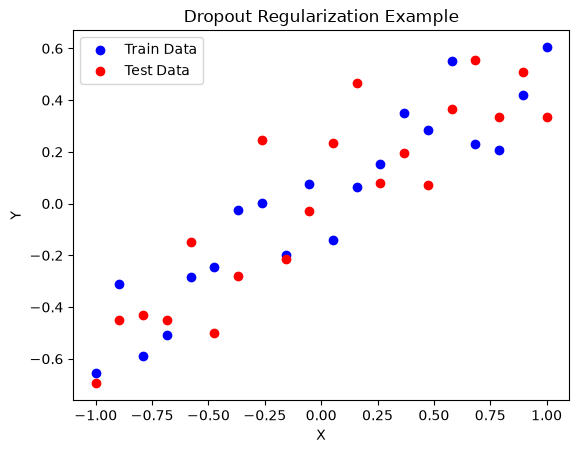

In [6]:
plt.scatter(x_train, y_train, label='Train Data', color='blue')
plt.scatter(x_test, y_test, label='Test Data', color='red')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dropout Regularization Example')
plt.legend()
plt.show()

Make ANN Model structure.

In [7]:
model_1 = Sequential()
model_1.add(Dense(128, input_dim=1, activation='relu'))
model_1.add(Dense(128, activation='relu'))
model_1.add(Dense(1, activation='linear'))
adam = Adam(learning_rate=0.01)
model_1.compile(loss='mean_squared_error', optimizer=adam, metrics=['mean_squared_error'])
history = model_1.fit(x_train, y_train, epochs=500, batch_size=4, verbose=0, validation_data=(x_test, y_test))

/home/hardik/Documents/learning_code/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1784480419.255259 1079622 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Store the loss value and metrics value.

In [8]:
train_loss, train_mse = model_1.evaluate(x_train, y_train, verbose=2)
test_loss, test_mse = model_1.evaluate(x_test, y_test, verbose=2)

1/1 - 0s - 151ms/step - loss: 0.0047 - mean_squared_error: 0.0047
1/1 - 0s - 50ms/step - loss: 0.0462 - mean_squared_error: 0.0462


Prediction of the model.

In [9]:
y_pred1 = model_1.predict(x_test)
y_pred1

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step


array([[-5.6349003e-01],
       [-5.3311706e-01],
       [-5.0274420e-01],
       [-4.5904973e-01],
       [-3.1846839e-01],
       [-2.0950022e-01],
       [-1.5985116e-02],
       [ 5.9948862e-04],
       [-1.8145078e-01],
       [ 8.8697448e-02],
       [-1.2533633e-01],
       [ 6.7062125e-02],
       [ 1.6162087e-01],
       [ 3.1783038e-01],
       [ 3.8741952e-01],
       [ 4.5578778e-01],
       [ 2.1134286e-01],
       [ 2.2108366e-01],
       [ 4.1728300e-01],
       [ 6.1437744e-01]], dtype=float32)

Plot the data and prediction line.

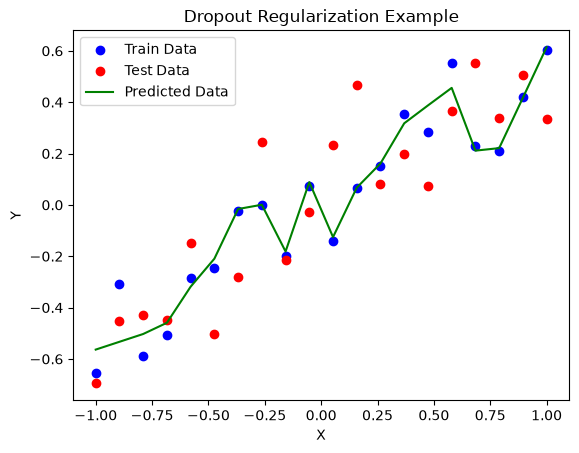

In [10]:
plt.figure()
plt.scatter(x_train, y_train, label='Train Data', color='blue')
plt.scatter(x_test, y_test, label='Test Data', color='red')
plt.plot(x_test, y_pred1, label='Predicted Data', color='green')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dropout Regularization Example')
plt.legend()
plt.show()

Make ANN Model  with dropout layer.

In [11]:
model_2 = Sequential()
model_2.add(Dense(128, input_dim=1, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(128, activation='relu'))
model_2.add(Dropout(0.5))
model_2.add(Dense(1, activation='linear'))
adam = Adam(learning_rate=0.01)
model_2.compile(loss='mean_squared_error', optimizer=adam, metrics=['mean_squared_error'])
dropout_history = model_2.fit(x_train, y_train, epochs=500, batch_size=4, verbose=2, validation_data=(x_test, y_test))

Epoch 1/500
5/5 - 1s - 221ms/step - loss: 0.0781 - mean_squared_error: 0.0781 - val_loss: 0.0471 - val_mean_squared_error: 0.0471
Epoch 2/500
5/5 - 0s - 25ms/step - loss: 0.2924 - mean_squared_error: 0.2924 - val_loss: 0.0315 - val_mean_squared_error: 0.0315
Epoch 3/500
5/5 - 0s - 24ms/step - loss: 0.0498 - mean_squared_error: 0.0498 - val_loss: 0.0812 - val_mean_squared_error: 0.0812
Epoch 4/500
5/5 - 0s - 29ms/step - loss: 0.0723 - mean_squared_error: 0.0723 - val_loss: 0.0674 - val_mean_squared_error: 0.0674
Epoch 5/500
5/5 - 0s - 28ms/step - loss: 0.0620 - mean_squared_error: 0.0620 - val_loss: 0.0453 - val_mean_squared_error: 0.0453
Epoch 6/500
5/5 - 0s - 27ms/step - loss: 0.0316 - mean_squared_error: 0.0316 - val_loss: 0.0280 - val_mean_squared_error: 0.0280
Epoch 7/500
5/5 - 0s - 28ms/step - loss: 0.0300 - mean_squared_error: 0.0300 - val_loss: 0.0378 - val_mean_squared_error: 0.0378
Epoch 8/500
5/5 - 0s - 26ms/step - loss: 0.0479 - mean_squared_error: 0.0479 - val_loss: 0.0492 

Store the loss value and metrics value.

In [12]:
train_loss, train_mse = model_2.evaluate(x_train, y_train, verbose=2)
test_loss, test_mse = model_2.evaluate(x_test, y_test, verbose=2)

1/1 - 0s - 149ms/step - loss: 0.0156 - mean_squared_error: 0.0156
1/1 - 0s - 47ms/step - loss: 0.0392 - mean_squared_error: 0.0392


Prediction of the new model.

In [13]:
y_pred2 = model_2.predict(x_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


Plot the data and the prediction line.

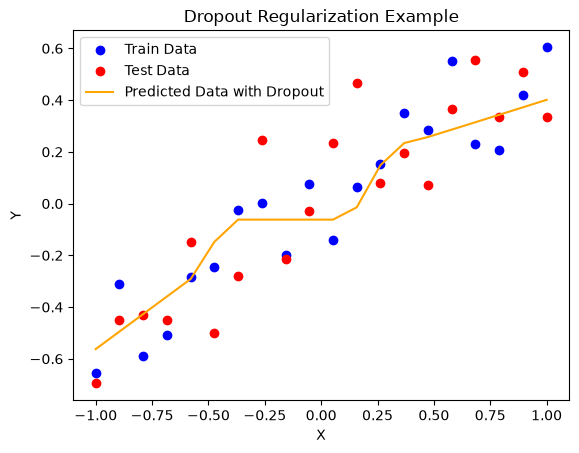

In [14]:
plt.figure()
plt.scatter(x_train, y_train, label='Train Data', color='blue')
plt.scatter(x_test, y_test, label='Test Data', color='red')
plt.plot(x_test, y_pred2, label='Predicted Data with Dropout', color='orange')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('Dropout Regularization Example')
plt.legend()
plt.show()